## Imports das Bibliotecas

In [115]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [116]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11432 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 11432 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    11432 non-null  int64 
 3   keywords               5072 non-null   object
 4   nome                   11432 non-null  object
 5   sexo                   11432 non-null  object
 6   nascimento             11432 non-null  object
 7   local_nascimento       11432 non-null  object
 8   escolaridade           11170 non-null  object
 9   uris.uriPartido        11432 non-null  object
 10  ementa_principal       11432 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           11432 non-null  object
 15  sigla_partido          1

In [117]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [118]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [119]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

In [120]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

# df["cor"].loc[(df["cor"] == "AMARELA") | (
#     df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [121]:
df['cor'].value_counts()

cor
BRANCA      3711
PARDA       1025
PRETA        224
INDÍGENA     180
AMARELA      103
Name: count, dtype: int64

In [122]:

## MODELOS SEM VIES

#Outros 100
#Brancos 100

#Gerar um classificar aleátorio / classificador sem viés tem que dar proximo a 50% de acurácia
# E macro F1 fica pior que 50%

#y_true = dados normais
#y_pred = se o valor for maior que 0.7 

#  f1_score(y_true, y_pred, average='macro')

branca = df["cor"].loc[(df["cor"] == 'BRANCA')].value_counts()
parda = df["cor"].loc[(df["cor"] == 'PARDA')].value_counts()
negra = df["cor"].loc[(df["cor"] == 'PRETA')].value_counts()
indigena = df["cor"].loc[(df["cor"] == 'INDÍGENA')].value_counts()
amarela = df["cor"].loc[(df["cor"] == 'AMARELA')].value_counts()

prob_brancos = (branca[0]/len(df["cor"]))
prob_pardas = (parda[0]/len(df["cor"]))
prob_negra = (negra[0]/len(df["cor"]))
prob_indigena = (indigena[0]/len(df["cor"]))
prob_amarela = (amarela[0]/len(df["cor"]))


y_prob = {'brancos': prob_brancos, 'pardas': prob_pardas, 'negra': prob_negra, 'indigena': prob_indigena, 'amarela': prob_amarela}


###obs: Aplicar para todos os modelos

In [123]:
y_prob

{'brancos': 0.70780087736029,
 'pardas': 0.19549876025176427,
 'negra': 0.042723631508678236,
 'indigena': 0.03433148960518787,
 'amarela': 0.019645241274079725}

In [124]:
df["cor"]

0       BRANCA
1        PARDA
2       BRANCA
3       BRANCA
4       BRANCA
         ...  
5238     PARDA
5239    BRANCA
5240    BRANCA
5241    BRANCA
5242    BRANCA
Name: cor, Length: 5243, dtype: object

In [125]:
df['cor'].value_counts()

cor
BRANCA      3711
PARDA       1025
PRETA        224
INDÍGENA     180
AMARELA      103
Name: count, dtype: int64

In [126]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,3711
1,PARDA,1025
2,PRETA,224
3,INDÍGENA,180
4,AMARELA,103


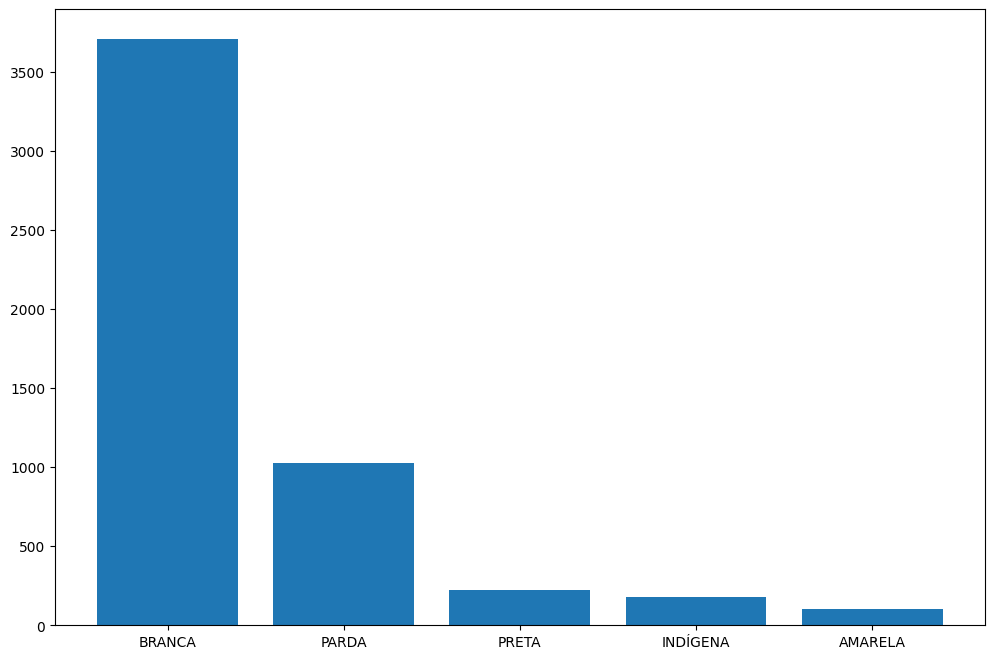

In [127]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [128]:
df["ementa"].dropna().count()

5243

## Bag Of Words

In [129]:
# nltk.download('stopwords')

In [130]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [131]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


## WORD CLOUD

In [132]:
le = LabelEncoder()

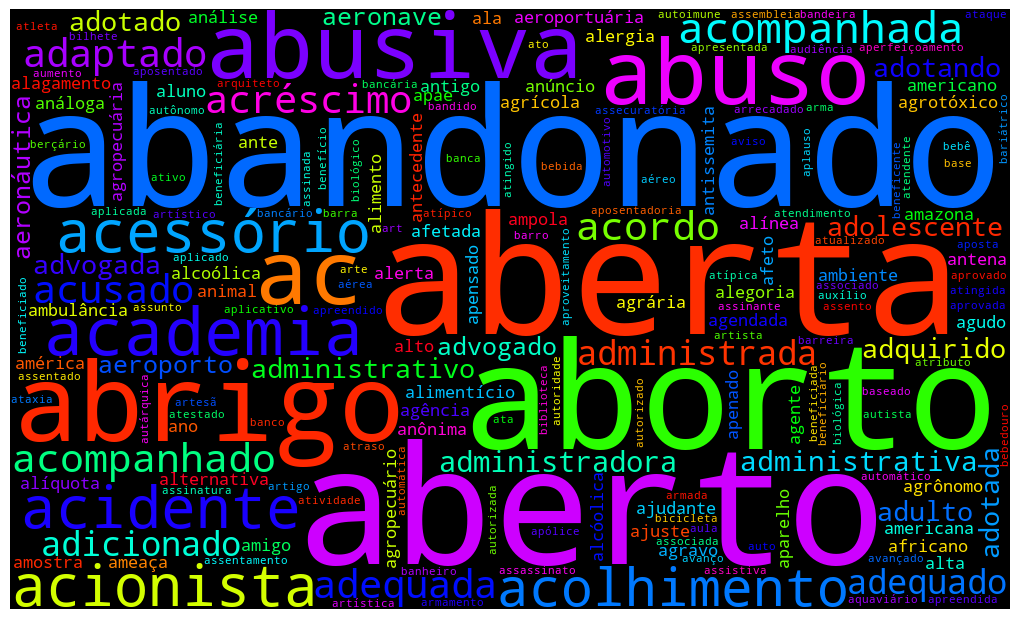

In [133]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [134]:
df_brancos = df[df["cor"] == "BRANCA"]
df_pardas  = df[df["cor"] == "PARDA"]
df_indigenas  = df[df["cor"] == "INDÍGENA"]
df_pretas  = df[df["cor"] == "PRETA"]
df_amarelas  = df[df["cor"] == "AMARELA"]



tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_pardas = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )


y_brancos = le.fit_transform(df_brancos["situacao"])
y_pardas = le.fit_transform(df_pardas["situacao"])
y_indigena = le.fit_transform(df_indigenas["situacao"])
y_preta = le.fit_transform(df_pretas["situacao"])
y_amarela = le.fit_transform(df_amarelas["situacao"])

In [135]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()
vocab_brancos = ' '.join(vocab_brancos)


In [136]:
vocab_brancos

'00 000 001 002 003 005 005766 009 01 010 013 014 015 016 019 02 02001 022 026 027 029 03 030 032 033 034 036 038 04 040 042 045 046 048 048410 05 052 06 069 07 070 072 074 076 078 079 08 080 087 09 090 095 096 098 099 10 100 1008 101 1010 10151 102 10273 10280 10284 103 10303 104 1045 1047 105 10583 106 1072 1074 1075 1077 108 10841 10975 11 110 1109 1111 112 1126 11260 115 1152 11530 116 1165 117 1175 119 1195 1198 11o 12 120 1205 121 122 1225 123 124 1241 1245 1249 125 126 127 128 129 1292 12965 13 130 131 132 133 134 135 1358 136 1366 1368 137 1371 1379 138 139 1394 13º 14 140 141 142 1425 143 144 145 1450 146 147 148 149 15 150 151 152 153 154 155 156 1560 1565 157 158 16 160 161 163 164 165 166 167 1671 168 17 171 172 173 174 175 176 1763 177 178 1784 1795 17ª 18 180 182 183 184 185 1853 186 187 1874 1875 188 189 19 1910 192 193 1937 1939 194 1940 1941 1942 1943 1945 1946 1948 195 1950 1955 1957 196 1960 1961 1962 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1

In [137]:
X_pardas = tf_idf.fit_transform(df_pardas["ementa"])
vocab_pardas = tf_idf.get_feature_names_out()
vocab_pardas = ' '.join(vocab_pardas)


In [138]:
X_indigena = tf_idf.fit_transform(df_indigenas["ementa"])
vocab_indigena = tf_idf.get_feature_names_out()
vocab_indigena = ' '.join(vocab_indigena)


In [139]:
X_pretas = tf_idf.fit_transform(df_pretas["ementa"])
vocab_pretas = tf_idf.get_feature_names_out()
vocab_pretas = ' '.join(vocab_pretas)


In [140]:
X_amarelas = tf_idf.fit_transform(df_amarelas["ementa"])
vocab_amarelas = tf_idf.get_feature_names_out()
vocab_amarelas = ' '.join(vocab_amarelas)


## GRUPO 1: PESSOA DE COR DE PELE BRANCA

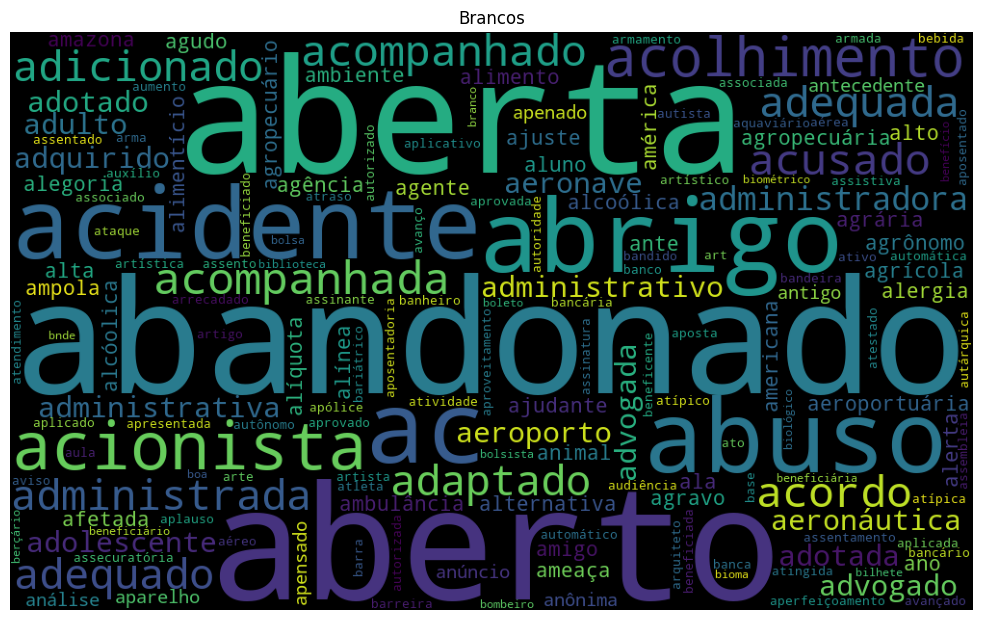

In [141]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    min_font_size=10).generate(vocab_brancos)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.title('Brancos')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

# PARDAS

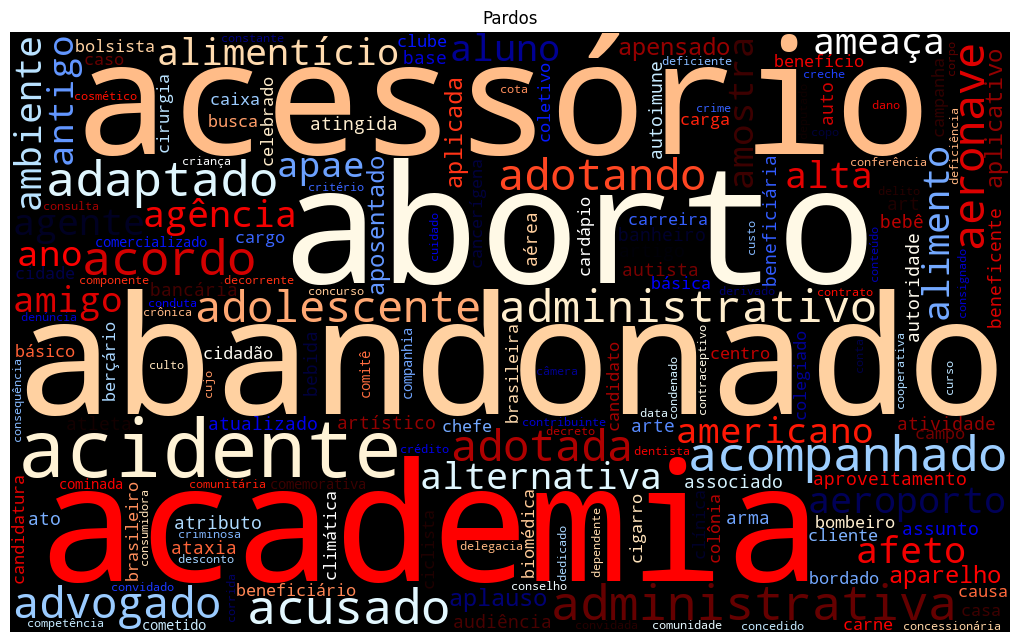

In [142]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='flag_r',
    min_font_size=10).generate(vocab_pardas)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Pardos')
plt.show()

# NEGRAS

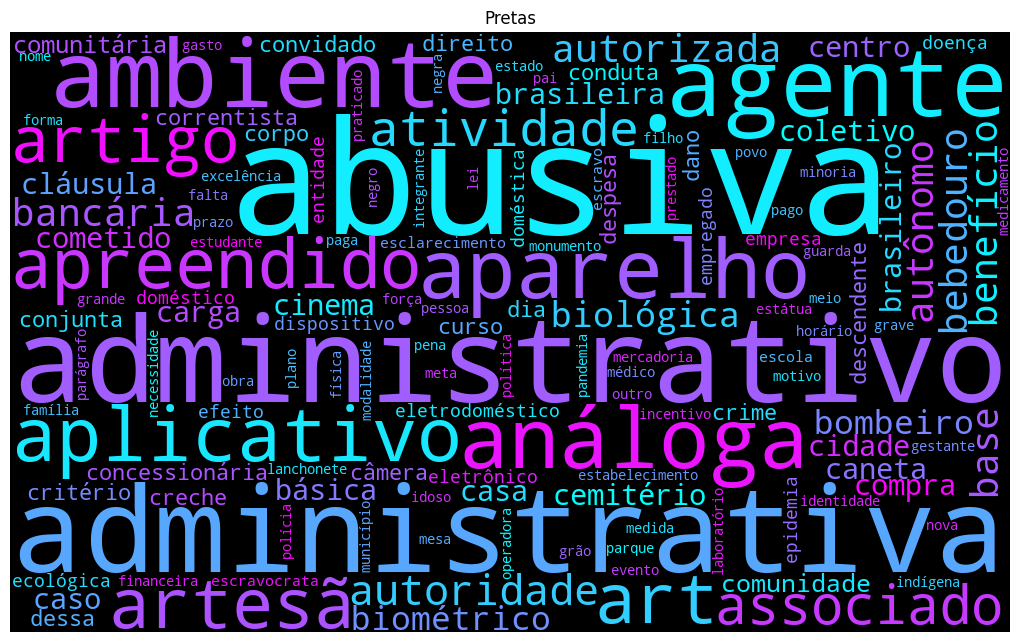

In [143]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='cool',
    min_font_size=10).generate(vocab_pretas)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Pretas')
plt.show()

# INDÍGENAS

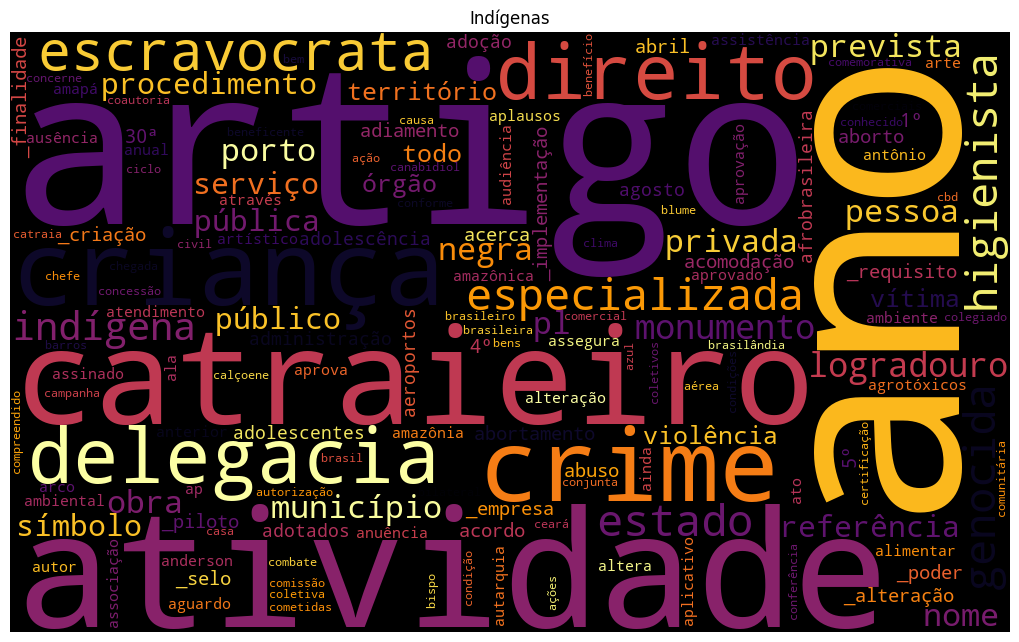

In [144]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='inferno',
    min_font_size=10).generate(vocab_indigena)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Indígenas')
plt.show()

# AMARELAS

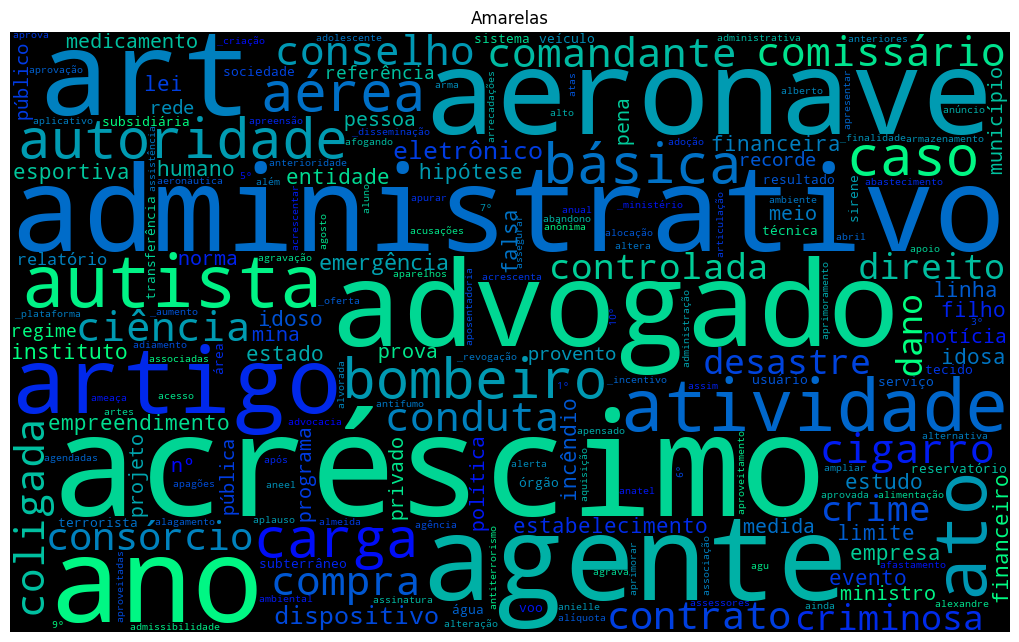

In [145]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='winter',
    min_font_size=10).generate(vocab_amarelas)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.title('Amarelas')
plt.show()

# PCA

In [146]:
df['cor']

0       BRANCA
1        PARDA
2       BRANCA
3       BRANCA
4       BRANCA
         ...  
5238     PARDA
5239    BRANCA
5240    BRANCA
5241    BRANCA
5242    BRANCA
Name: cor, Length: 5243, dtype: object

In [147]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

In [148]:
y

0       1
1       3
2       1
3       1
4       1
       ..
5238    3
5239    1
5240    1
5241    1
5242    1
Name: cor, Length: 5243, dtype: int32

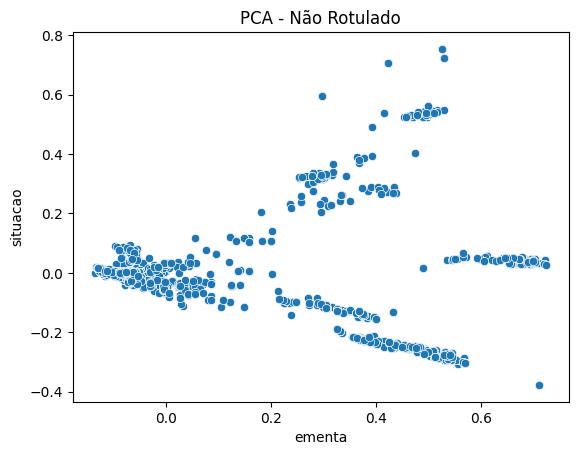

In [149]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

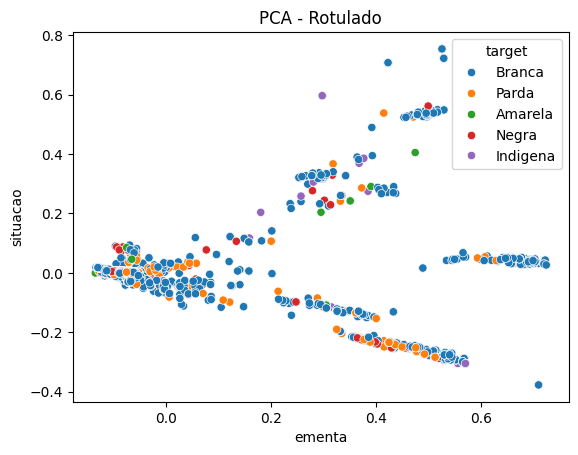

In [150]:
y_map = {0: 'Amarela', 1: 'Branca', 2: 'Indigena', 3: 'Parda', 4: 'Negra'}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

## Treino do Modelo

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [153]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Amarela","Branca", "Indígena", 'Parda', 'Negra'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [154]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [155]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.19051516 0.20828328 0.21357632 0.28408457 0.22938066]
Media da Accuracy:  0.6965470568116492
Media da MACRO F1:  0.22516799823494676
Desvio Padrão da MACRO F1:  0.03196619757937239


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.24      0.35      0.29        17
           1       0.82      0.76      0.79       756
           2       0.38      0.75      0.50        36
           3       0.44      0.47      0.45       200
           4       0.18      0.17      0.18        40

    accuracy                           0.68      1049
   macro avg       0.41      0.50      0.44      1049
weighted avg       0.70      0.68      0.69      1049



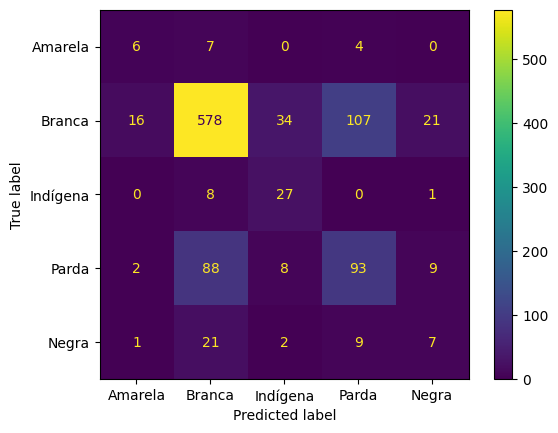

In [156]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [157]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.3048169  0.27751652 0.45662912 0.3821211  0.34407413]
Media da Accuracy:  0.6633580509245446
Media da MACRO F1:  0.35303155426676486
Desvio Padrão da MACRO F1:  0.06274721609298563


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.26      0.35      0.30        17
           1       0.83      0.78      0.80       756
           2       0.41      0.75      0.53        36
           3       0.44      0.47      0.46       200
           4       0.26      0.20      0.23        40

    accuracy                           0.69      1049
   macro avg       0.44      0.51      0.46      1049
weighted avg       0.71      0.69      0.70      1049



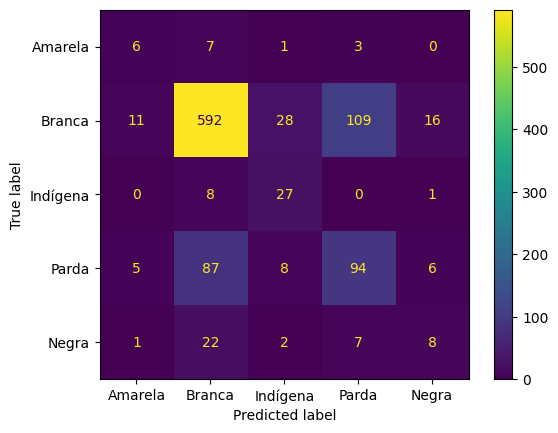

In [158]:
model_SGD.fit(X_train, y_train)
y_pred = model_SGD.predict(X_test)
evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# K Neighbors Classifier

In [159]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.20262499 0.2405252  0.41309417 0.36525045 0.25244872]
Media da Accuracy:  0.6585846935285514
Media da MACRO F1:  0.2947887043190729
Desvio Padrão da MACRO F1:  0.08024013222106204


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.07      0.53      0.12        17
           1       0.87      0.30      0.45       756
           2       0.29      0.67      0.40        36
           3       0.30      0.60      0.40       200
           4       0.09      0.38      0.15        40

    accuracy                           0.38      1049
   macro avg       0.32      0.49      0.30      1049
weighted avg       0.70      0.38      0.42      1049



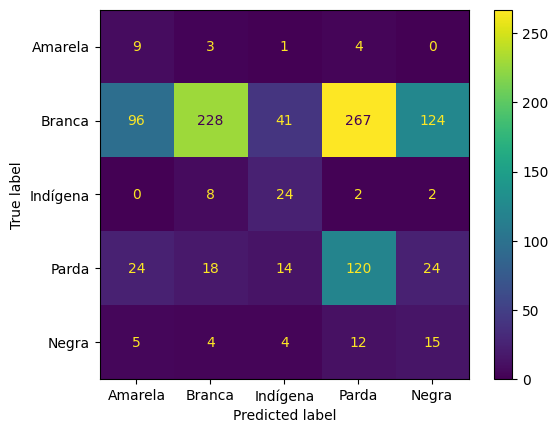

In [160]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [161]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.23821842 0.28745931 0.46762953 0.42512712 0.35163527]
Media da Accuracy:  0.667555432654873
Media da MACRO F1:  0.354013932463159
Desvio Padrão da MACRO F1:  0.08462785202936234


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.29      0.29      0.29        17
           1       0.82      0.81      0.81       756
           2       0.43      0.72      0.54        36
           3       0.46      0.46      0.46       200
           4       0.30      0.20      0.24        40

    accuracy                           0.71      1049
   macro avg       0.46      0.50      0.47      1049
weighted avg       0.71      0.71      0.70      1049



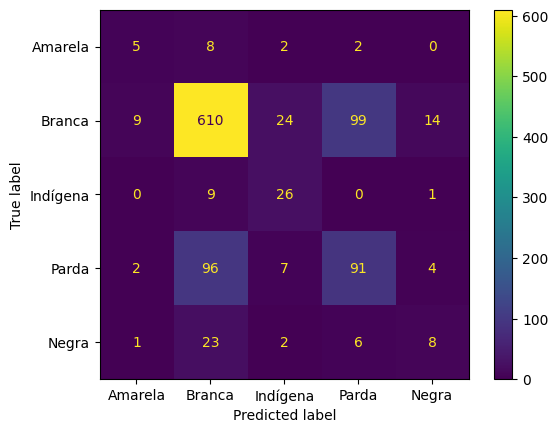

In [162]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [163]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.16873713 0.19293919 0.37650514 0.35471829 0.29526278]
Media da Accuracy:  0.7226793602049207
Media da MACRO F1:  0.27763250454515886
Desvio Padrão da MACRO F1:  0.08373768907065357


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.44      0.24      0.31        17
           1       0.78      0.92      0.84       756
           2       0.67      0.61      0.64        36
           3       0.57      0.27      0.37       200
           4       0.38      0.12      0.19        40

    accuracy                           0.75      1049
   macro avg       0.57      0.43      0.47      1049
weighted avg       0.71      0.75      0.71      1049



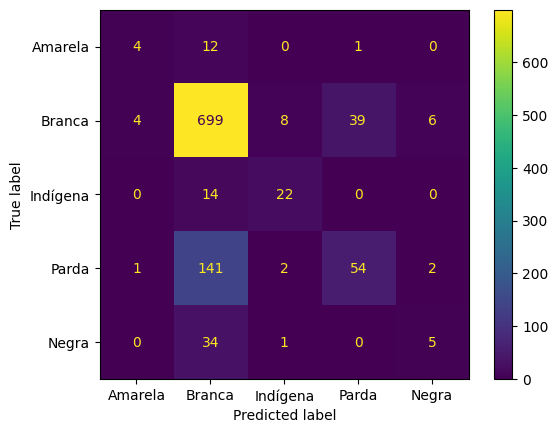

In [164]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [165]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.25322533 0.24089666 0.40481192 0.35967324 0.32299805]
Media da Accuracy:  0.6034867813038953
Media da MACRO F1:  0.3163210414228365
Desvio Padrão da MACRO F1:  0.06232902388620172


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.13      0.18      0.15        17
           1       0.82      0.79      0.80       756
           2       0.45      0.72      0.55        36
           3       0.42      0.41      0.42       200
           4       0.17      0.20      0.18        40

    accuracy                           0.68      1049
   macro avg       0.40      0.46      0.42      1049
weighted avg       0.69      0.68      0.68      1049



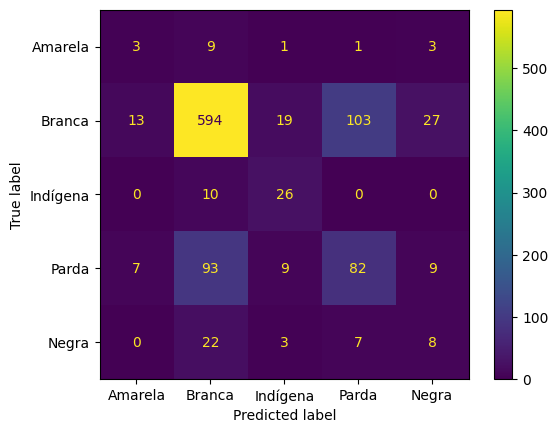

In [166]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [167]:
balanceamento = []

rng = np.random.default_rng(62)
numbers = rng.random(len(y_test)+1)



for i in range(len(numbers)):
    if i < prob_brancos:
        # balanceamento.append(1)
        balanceamento.append(df.loc[df['cor'] == 1].sample(1))

    elif i > prob_brancos and i < prob_brancos + prob_pardas:
        # balanceamento.append(3)
        balanceamento.append(df.loc[df['cor'] == 3].sample(1))

    elif i > prob_brancos + prob_pardas and i < prob_brancos + prob_pardas + prob_negra:
        # balanceamento.append(4)
        balanceamento.append(df.loc[df['cor'] == 4 ].sample(1))    
    elif i > prob_brancos + prob_pardas + prob_negra and i < prob_brancos + prob_pardas + prob_negra + prob_indigena:
        # balanceamento.append(2)
        balanceamento.append(df.loc[df['cor'] == 2].sample(1))

    elif i > prob_brancos + prob_pardas + prob_negra + prob_indigena + prob_amarela:
        # balanceamento.append(0)
        balanceamento.append(df.loc[df['cor'] == 0].sample(1))        

df = pd.concat(balanceamento)

In [168]:




from sklearn.metrics import f1_score

f1_score(y_test, df['cor'], average='macro')

0.006913378111026353